In [5]:
# 1. Import the core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make our plots look nice
sns.set_theme(style="darkgrid")

# 2. Load the dataset (Make sure creditcard.csv is in your project folder!)
print("Loading data... this might take a second for 284k rows!")
df = pd.read_csv('/tf/project/creditcard.csv')

# 3. Take a peek at the first 5 rows
display(df.head())

# 4. Check the massive imbalance between Normal (0) and Fraud (1)
print("\n--- Class Distribution ---")
print(df['Class'].value_counts(normalize=True) * 100)

Loading data... this might take a second for 284k rows!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Class Distribution ---
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [6]:
from sklearn.preprocessing import StandardScaler

print("1. Scaling the data...")
# We use StandardScaler to squish Time and Amount so they have a mean of 0 and a standard deviation of 1
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

print("2. Separating Normal vs Fraud...")
# Split the dataset
normal_data = df[df['Class'] == 0]
fraud_data = df[df['Class'] == 1]

print("3. Dropping the labels (Going Unsupervised!)...")
# Autoencoders are unsupervised! They don't want the 'Class' answers.
# We just want it to learn what a "normal" transaction looks like.
x_train = normal_data.drop(['Class'], axis=1)
x_fraud = fraud_data.drop(['Class'], axis=1)

# Convert from Pandas DataFrames to raw NumPy arrays (TensorFlow loves NumPy)
x_train = x_train.values
x_fraud = x_fraud.values

print("\n--- Mission Accomplished ---")
print(f"Normal Training Data Shape: {x_train.shape}")
print(f"Fraud Testing Data Shape: {x_fraud.shape}")

1. Scaling the data...
2. Separating Normal vs Fraud...
3. Dropping the labels (Going Unsupervised!)...

--- Mission Accomplished ---
Normal Training Data Shape: (284315, 30)
Fraud Testing Data Shape: (492, 30)


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

print("Architecting the Neural Network...")

# We have 30 columns in our training data
input_dim = x_train.shape[1] 

# --- THE ENCODER ---
# 1. The Front Door
input_layer = Input(shape=(input_dim,), name="Input_Layer")

# 2. Shrink it down (Compressing)
encoder = Dense(14, activation="relu", name="Encoder_Layer_1")(input_layer)
# The Bottleneck! The data is now compressed to just 7 numbers.
encoder = Dense(7, activation="relu", name="Bottleneck_Layer")(encoder) 

# --- THE DECODER ---
# 3. Build it back up (Reconstructing)
decoder = Dense(14, activation="relu", name="Decoder_Layer_1")(encoder)
# 4. The Exit Door (Must match our original 30 columns!)
decoder = Dense(input_dim, activation="linear", name="Output_Layer")(decoder)

# --- BRING IT TOGETHER ---
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile it using Mean Squared Error (MSE) to measure how bad its reconstructions are
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

print("\n--- Model Architecture ---")
autoencoder.summary()

I0000 00:00:1776195578.291680     406 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776195579.740802     406 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776195585.060063     406 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Architecting the Neural Network...

--- Model Architecture ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Layer_1 (Dense)         │ (None, 14)             │           434 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck_Layer (Dense)        │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Layer_1 (Dense)         │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 30)             │           450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101 (4.30 KB)

 Trainable params: 1,101 (4.30 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("Commencing Training Phase (This might take a minute or two!)...")

# Train the model! Notice how we pass x_train for BOTH the input and the target.
history = autoencoder.fit(
    x=x_train, 
    y=x_train, # "Copy your homework!"
    epochs=20, # Number of times it loops through the entire dataset
    batch_size=256, 
    validation_split=0.2, # Hold back 20% to test itself during training
    shuffle=True,
    verbose=1 # Shows the progress bar
)

print("\n--- Training Complete! ---")

Commencing Training Phase (This might take a minute or two!)...
Epoch 1/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.7178 - val_loss: 0.5518
Epoch 2/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.4797 - val_loss: 0.4406
Epoch 3/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.4133 - val_loss: 0.4138
Epoch 4/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3879 - val_loss: 0.3970
Epoch 5/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3758 - val_loss: 0.3907
Epoch 6/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3683 - val_loss: 0.3857
Epoch 7/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3621 - val_loss: 0.3771
Epoch 8/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3548 - val_loss: 0.3736
Epoch 9/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3473 - val_loss: 0.3696
Epoch 10/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3419 - val_loss: 0.3648
Epoch 11/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3381 - val_l

Calculating Reconstruction Errors...
8885/8885 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


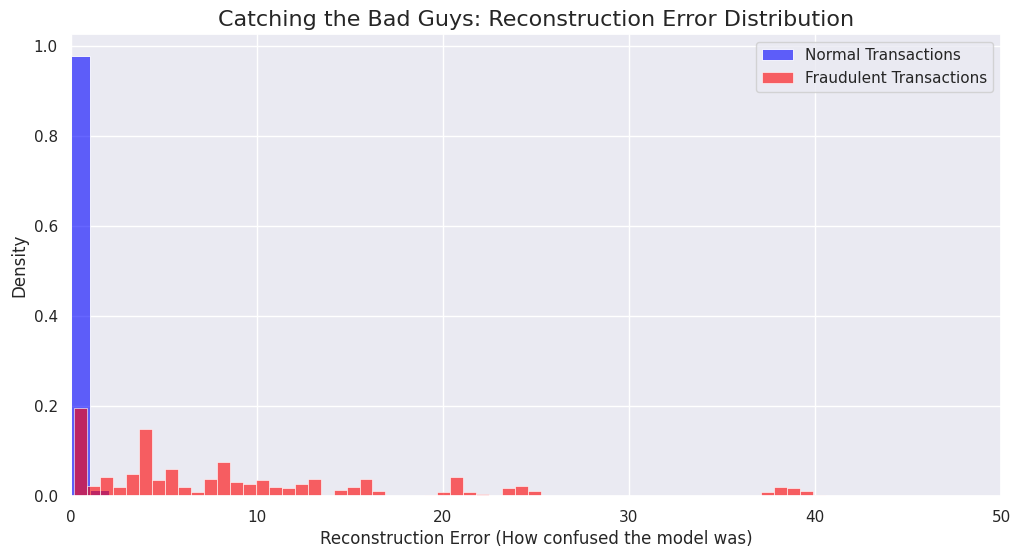

In [9]:
print("Calculating Reconstruction Errors...")

# 1. Force the model to rebuild the data
reconstructions_normal = autoencoder.predict(x_train)
reconstructions_fraud = autoencoder.predict(x_fraud)

# 2. Calculate the Mean Squared Error (How different is the output from the input?)
mse_normal = np.mean(np.power(x_train - reconstructions_normal, 2), axis=1)
mse_fraud = np.mean(np.power(x_fraud - reconstructions_fraud, 2), axis=1)

# 3. Plot the final masterpiece
plt.figure(figsize=(12, 6))
# Plot Normal transactions (Blue)
sns.histplot(mse_normal, bins=100, color="blue", alpha=0.6, label="Normal Transactions", stat="density")
# Plot Fraud transactions (Red)
sns.histplot(mse_fraud, bins=100, color="red", alpha=0.6, label="Fraudulent Transactions", stat="density")

plt.title("Catching the Bad Guys: Reconstruction Error Distribution", fontsize=16)
plt.xlabel("Reconstruction Error (How confused the model was)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, 50) # Zooming in on the most important part of the graph
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating the Model at Threshold = 2.8...\n")

# 1. Set our magic number
THRESHOLD = 2.6

# 2. Make our final predictions
# If the error is GREATER than 2.8, we predict it is Fraud (True)
# If it is LESS than 2.8, we predict it is Normal (False)
pred_normal = mse_normal > THRESHOLD
pred_fraud = mse_fraud > THRESHOLD

# 3. Combine everything to grade the model
# We create a true labels array (0 for normal, 1 for fraud)
y_true = np.append(np.zeros(len(mse_normal)), np.ones(len(mse_fraud)))
# We combine our predictions
y_pred = np.append(pred_normal, pred_fraud)

# 4. Print the final report card!
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(f"True Negatives (Normal passed): {cm[0][0]}")
print(f"False Positives (Normal blocked): {cm[0][1]}")
print(f"False Negatives (Fraud missed): {cm[1][0]}")
print(f"True Positives (Fraud caught): {cm[1][1]}\n")

print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Fraud (1)']))

Evaluating the Model at Threshold = 2.8...

--- Confusion Matrix ---
True Negatives (Normal passed): 283586
False Positives (Normal blocked): 729
False Negatives (Fraud missed): 94
True Positives (Fraud caught): 398

--- Classification Report ---
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00    284315
   Fraud (1)       0.35      0.81      0.49       492

    accuracy                           1.00    284807
   macro avg       0.68      0.90      0.75    284807
weighted avg       1.00      1.00      1.00    284807



In [12]:
print("Saving the model to your hard drive...")

# Save the entire architecture, weights, and training state
autoencoder.save('../fraud_autoencoder.keras')

print("Model saved successfully! Check your Windows folder!")

Saving the model to your hard drive...
Model saved successfully! Check your Windows folder!


In [13]:
# The Real-World Checking Function
def check_new_transaction(transaction_data, trained_model, threshold=2.8):
    # 1. Ask the model to rebuild this single transaction
    reconstruction = trained_model.predict(transaction_data, verbose=0)
    
    # 2. Calculate the Reconstruction Error
    mse = np.mean(np.power(transaction_data - reconstruction, 2), axis=1)
    
    # 3. Make the final call!
    is_fraud = mse > threshold
    
    print(f"Error Score: {mse[0]:.2f} (Threshold: {threshold})")
    if is_fraud[0]:
        print("🚨 ALERT: FRAUD DETECTED! Blocking transaction.")
    else:
        print("✅ Normal behavior. Transaction Approved.")

# --- Let's test it out! ---
print("--- Simulating a Customer Swiping their Card ---")

print("\nTest 1: Passing in a known Normal transaction...")
# We grab the very first normal row, and reshape it so TensorFlow knows it's a single batch
check_new_transaction(x_train[0].reshape(1, -1), autoencoder)

print("\nTest 2: Passing in a known Fraudulent transaction...")
check_new_transaction(x_fraud[0].reshape(1, -1), autoencoder)

--- Simulating a Customer Swiping their Card ---

Test 1: Passing in a known Normal transaction...
Error Score: 0.18 (Threshold: 2.8)
✅ Normal behavior. Transaction Approved.

Test 2: Passing in a known Fraudulent transaction...
Error Score: 3.03 (Threshold: 2.8)
🚨 ALERT: FRAUD DETECTED! Blocking transaction.
